# 04 · data-driven zoning (WPP 573)

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd

def cari_akar(mulai=None):
    p = Path(mulai or Path.cwd()).resolve()
    for kandidat in [p, *p.parents]:
        if (kandidat / "src" / "zonasi.py").exists():
            return kandidat
    raise FileNotFoundError(
        "tidak menemukan akar proyek (folder yang berisi src/zonasi.py) "
        f"dari {p}. Buka notebook ini dari dalam folder 02_Riset-Data.")

AKAR = cari_akar()
sys.path.insert(0, str(AKAR / "src"))
import zonasi as Z

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

print(f"akar proyek : {AKAR}")
print(f"folder kerja: {Path.cwd()}")
print(f"Z.AKAR      : {Z.AKAR}   (dijangkarkan dari __file__, bukan dari cwd)")
print(f"data/raw    : {Z.RAW}  ->  {'ADA' if Z.RAW.is_dir() else 'TIDAK ADA'}")
print("modul zonasi siap")

akar proyek : /sessions/rcw-01b8k8dxpmldhcspkmrflhfq/mnt/02. A-Case IPB/02_Riset-Data
folder kerja: /sessions/rcw-01b8k8dxpmldhcspkmrflhfq/mnt/02. A-Case IPB/02_Riset-Data/notebooks
Z.AKAR      : /sessions/rcw-01b8k8dxpmldhcspkmrflhfq/mnt/02. A-Case IPB/02_Riset-Data   (dijangkarkan dari __file__, bukan dari cwd)
data/raw    : /sessions/rcw-01b8k8dxpmldhcspkmrflhfq/mnt/02. A-Case IPB/02_Riset-Data/data/raw  ->  ADA
modul zonasi siap


## load, coastal cell definition

In [2]:
da = Z.muat()
waktu = pd.to_datetime(da.waktu.values)

laut, pes      = Z.klasifikasi(da, sertakan_tepi=False)
_,    pes_lama = Z.klasifikasi(da, sertakan_tepi=True)

print(f"periode          : {waktu.min().date()} s/d {waktu.max().date()}  ({len(waktu)} hari)")
print(f"grid             : {laut.shape[0]} lintang x {laut.shape[1]} bujur")
print(f"sel laut         : {laut.sum()}")
print(f"sel darat        : {(~laut).sum()}")
print()
print(f"pesisir (benar)  : {pes.sum()}")
print(f"pesisir (lama)   : {pes_lama.sum()}")
print(f"selisih          : {pes_lama.sum() - pes.sum()} sel yang sebenarnya laut lepas di tepi kotak")

periode          : 2021-01-01 s/d 2025-12-31  (1826 hari)
grid             : 17 lintang x 49 bujur
sel laut         : 776
sel darat        : 57

pesisir (benar)  : 114
pesisir (lama)   : 218
selisih          : 104 sel yang sebenarnya laut lepas di tepi kotak


In [3]:
lonv, latv = da.longitude.values, da.latitude.values

def sebaran(mask, nama):
    ii, jj = np.where(mask)
    return (pd.DataFrame({"bujur": lonv[jj], nama: 1})
              .groupby("bujur")[nama].sum())

bandingan = pd.concat([sebaran(pes_lama, "lama"), sebaran(pes, "benar")], axis=1).fillna(0).astype(int)
bandingan["selisih"] = bandingan.lama - bandingan.benar
print(bandingan.loc[[104.0, 104.5, 113.0, 127.5, 128.0]].to_string())
print()
print("Di 104,0 dan 128,0 BT: seluruh kolom ditandai pesisir oleh definisi lama,")
print("padahal hampir semuanya laut lepas di tepi kotak unduhan.")

       lama  benar  selisih
bujur                      
104.0    17      0       17
104.5     2      0        2
113.0     4      3        1
127.5     6      5        1
128.0    17      3       14

Di 104,0 dan 128,0 BT: seluruh kolom ditandai pesisir oleh definisi lama,
padahal hampir semuanya laut lepas di tepi kotak unduhan.


## correlation vs distance

In [4]:
mat_laut, idx_laut = Z.matriks(da, laut)
lon_l = np.array([lonv[j] for _, j in idx_laut])
lat_l = np.array([latv[i] for i, _ in idx_laut])
D_laut = Z.jarak_km(lat_l, lon_l)

d0,  nug,  pusat,  rata  = Z.peluruhan(D_laut, Z.korelasi(mat_laut))
anom = Z.anomali(mat_laut, waktu)
d0a, nuga, pusat_a, rata_a = Z.peluruhan(D_laut, Z.korelasi(anom))

def rho_pada(pusat, rata, jarak):
    return np.interp(jarak, pusat, rata)

print(f"panjang korelasi d0, deret mentah : {d0:7.0f} km")
print(f"panjang korelasi d0, anomali      : {d0a:7.0f} km")
print()
print(f"korelasi pada 438 km (lebar zona lama 4 deg):")
print(f"  deret mentah : {rho_pada(pusat, rata, 438):.3f}")
print(f"  anomali      : {rho_pada(pusat_a, rata_a, 438):.3f}")

panjang korelasi d0, deret mentah :    1809 km
panjang korelasi d0, anomali      :    1560 km

korelasi pada 438 km (lebar zona lama 4 deg):
  deret mentah : 0.795
  anomali      : 0.775


## clustering (ward + adjacency)

In [5]:
mat, idx = Z.matriks(da, pes)
lon = np.array([lonv[j] for _, j in idx])
lat = np.array([latv[i] for i, _ in idx])

R    = Z.korelasi(mat)
X    = Z.baku(mat)
D_p  = Z.jarak_km(lat, lon)
conn, n_komponen = Z.konektivitas(D_p)

print(f"sel pesisir yang dikelompokkan : {len(idx)}")
print(f"graf ketetanggaan (radius {Z.RADIUS_TETANGGA_KM:.0f} km) : {n_komponen} komponen")
print("  (komponen = gugus pulau yang terpisah lebih jauh dari radius; wajar untuk kepulauan)")

sel pesisir yang dikelompokkan : 114
graf ketetanggaan (radius 120 km) : 4 komponen
  (komponen = gugus pulau yang terpisah lebih jauh dari radius; wajar untuk kepulauan)


### choosing k

In [6]:
diag, label_per_k = Z.pilih_k(mat, X, R, conn, lon)
diag.round(4)

,k,silhouette,korelasi_intra,korelasi_inter,selisih,keterwakilan_rata,keterwakilan_p10,keterwakilan_min,sel_min,sel_maks
0,2,0.3786,0.5919,0.3795,0.2123,0.7994,0.6573,0.3792,31,83
1,3,0.3686,0.6677,0.3877,0.2800,0.8342,0.6935,0.4403,17,66
2,4,0.3568,0.7183,0.4132,0.3051,0.8603,0.6652,0.4403,15,51
3,5,0.4048,0.7303,0.4116,0.3187,0.8805,0.7242,0.5179,4,51
4,6,0.4598,0.7749,0.4170,0.3580,0.8986,0.7870,0.5924,4,44
5,7,0.4554,0.8252,0.4377,0.3875,0.9114,0.8226,0.5156,4,31
6,8,0.5233,0.8636,0.4400,0.4236,0.9286,0.8616,0.6299,4,31
7,9,0.5434,0.8754,0.4444,0.4309,0.9365,0.8681,0.6299,4,31
8,10,0.5167,0.8846,0.4489,0.4356,0.9417,0.8809,0.6299,4,31
9,11,0.4900,0.8886,0.4660,0.4225,0.9464,0.8809,0.6299,4,18


In [7]:
k = Z.pilih_k_terkecil(diag)
print(f"k terpilih = {k}  (k terkecil dengan keterwakilan persentil-10 >= {Z.AMBANG_KETERWAKILAN})")
print()
print("Perhatikan kolom silhouette: nilainya TIDAK memuncak pada k yang wajar,")
print("melainkan terus naik sampai ujung rentang yang diuji. Itu ciri medan GRADIEN —")
print("gelombang berubah mulus dari barat ke timur, bukan membentuk gugus terpisah.")
print("Karena itu silhouette dilaporkan sebagai diagnostik, tetapi tidak dipakai memilih k.")

k terpilih = 6  (k terkecil dengan keterwakilan persentil-10 >= 0.75)

Perhatikan kolom silhouette: nilainya TIDAK memuncak pada k yang wajar,
melainkan terus naik sampai ujung rentang yang diuji. Itu ciri medan GRADIEN —
gelombang berubah mulus dari barat ke timur, bukan membentuk gugus terpisah.
Karena itu silhouette dilaporkan sebagai diagnostik, tetapi tidak dipakai memilih k.


## result

In [8]:
label = label_per_k[k]
tp_grid  = Z.terpapar_samudra(da, laut)
terpapar = np.array([tp_grid[i, j] for i, j in idx])

ringkas = Z.ringkas_zona(mat, idx, lat, lon, label, waktu, R, terpapar)
ringkas[["zona", "n_sel", "lon_min", "lon_maks", "lat_min", "lat_maks",
         "swh_rata", "ambang_m", "korelasi_intra", "frac_terpapar", "watak"]].round(3)

,zona,n_sel,lon_min,lon_maks,lat_min,lat_maks,swh_rata,ambang_m,korelasi_intra,frac_terpapar,watak
0,1,4,109.0,110.5,-7.0,-7.0,0.328,0.620,0.966,0.000,terlindung / laut dalam
1,2,31,106.0,119.0,-9.0,-7.0,1.745,2.297,0.902,1.000,terpapar Samudra Hindia
2,3,7,113.0,115.5,-8.0,-7.0,0.406,0.589,0.828,0.286,terlindung / laut dalam
3,4,15,117.0,122.5,-8.5,-8.0,0.577,0.875,0.842,0.467,terlindung / laut dalam
4,5,44,119.5,127.5,-10.5,-8.0,0.881,1.242,0.698,0.477,peralihan
5,6,13,125.0,128.0,-15.0,-13.5,0.633,1.093,0.828,0.385,terlindung / laut dalam


In [9]:
for kk in sorted(label_per_k):
    lab = label_per_k[kk]
    rata_zona = {z: np.nanmean(mat[:, lab == z]) for z in set(lab)}
    z_terpapar = max(rata_zona, key=rata_zona.get)
    n = int((lab == z_terpapar).sum())
    print(f"k={kk:2d}  zona terpapar: {n:2d} sel, SWH {rata_zona[z_terpapar]:.2f} m")

k= 2  zona terpapar: 31 sel, SWH 1.75 m
k= 3  zona terpapar: 31 sel, SWH 1.75 m
k= 4  zona terpapar: 31 sel, SWH 1.75 m
k= 5  zona terpapar: 31 sel, SWH 1.75 m
k= 6  zona terpapar: 31 sel, SWH 1.75 m
k= 7  zona terpapar: 31 sel, SWH 1.75 m
k= 8  zona terpapar: 31 sel, SWH 1.75 m
k= 9  zona terpapar: 31 sel, SWH 1.75 m
k=10  zona terpapar: 31 sel, SWH 1.75 m
k=11  zona terpapar: 13 sel, SWH 1.94 m
k=12  zona terpapar: 13 sel, SWH 1.94 m


## seasonal cycle per zone

In [10]:
sik = Z.siklus_bulanan(mat, label, waktu)
pivot = sik.pivot(index="bulan", columns="zona", values="swh_ternormalisasi").round(3)
print(pivot.to_string())
print()
print(ringkas[["zona", "swh_musim_barat", "swh_musim_timur", "rasio_barat_timur", "watak"]]
      .round(3).to_string(index=False))
print()
print("rasio > 1 berarti musim BARAT lebih berbahaya daripada musim TIMUR di zona itu.")

zona       1      2      3      4      5      6
bulan                                          
1      1.751  0.899  1.086  1.407  0.978  1.280
2      1.820  0.956  1.220  1.513  1.063  1.240
3      1.217  0.880  0.855  0.976  0.784  0.835
4      0.666  0.905  0.691  0.734  0.854  0.956
5      0.665  1.003  0.997  0.881  1.122  1.213
6      0.712  1.098  1.062  0.947  1.177  1.111
7      0.838  1.204  1.222  1.089  1.269  1.070
8      0.884  1.209  1.289  1.083  1.232  0.935
9      0.821  1.115  1.159  0.931  1.071  0.854
10     0.685  1.004  0.898  0.751  0.890  0.806
11     0.675  0.813  0.656  0.618  0.693  0.759
12     1.303  0.907  0.872  1.092  0.866  0.954



 zona  swh_musim_barat  swh_musim_timur  rasio_barat_timur                   watak
    1            0.532            0.266              2.002 terlindung / laut dalam
    2            1.606            2.042              0.787 terpapar Samudra Hindia
    3            0.430            0.484              0.889 terlindung / laut dalam
    4            0.772            0.600              1.287 terlindung / laut dalam
    5            0.853            1.080              0.790               peralihan
    6            0.733            0.657              1.115 terlindung / laut dalam

rasio > 1 berarti musim BARAT lebih berbahaya daripada musim TIMUR di zona itu.


## vs old 4° cut

In [11]:
zona_lama = np.digitize(lon, np.arange(104, 129, 4.0))
rep_lama  = Z.keterwakilan(mat, zona_lama)
rep_baru  = Z.keterwakilan(mat, label)

banding = pd.DataFrame({
    "zonasi lama (bujur 4 derajat)": [len(set(zona_lama)), rep_lama.mean(),
                                      np.percentile(rep_lama, 10), rep_lama.min()],
    f"zonasi baru (k={k}, berbasis data)": [len(set(label)), rep_baru.mean(),
                                            np.percentile(rep_baru, 10), rep_baru.min()],
}, index=["jumlah zona", "keterwakilan rata-rata",
          "keterwakilan persentil-10", "keterwakilan minimum"]).round(3)
banding

,zonasi lama (bujur 4 derajat),"zonasi baru (k=6, berbasis data)"
jumlah zona,7.000,6.000
keterwakilan rata-rata,0.827,0.899
keterwakilan persentil-10,0.656,0.787
keterwakilan minimum,0.278,0.592


## figures

In [12]:
hasil = Z.jalankan(simpan=True, verbose=False)

print("tersimpan (jalur absolut, tidak bergantung folder kerja):")
for f in [Z.FIG / "fig_zonasi_peta.png",
          Z.FIG / "fig_zonasi_diagnostik.png",
          Z.DIM / "dim_zona_wpp573.csv",
          Z.PROCESSED / "sel_zona_wpp573.csv",
          Z.TAB / "diagnostik_zonasi_wpp573.csv",
          Z.TAB / "siklus_musiman_zona_wpp573.csv",
          Z.TAB / "zonasi_meta.json"]:
    print(f"  {'OK    ' if f.exists() else 'HILANG'} {f.relative_to(Z.AKAR)}")

tersimpan (jalur absolut, tidak bergantung folder kerja):
  OK     output/figures/fig_zonasi_peta.png
  OK     output/figures/fig_zonasi_diagnostik.png
  OK     data/dim/dim_zona_wpp573.csv
  OK     data/processed/sel_zona_wpp573.csv
  OK     output/tables/diagnostik_zonasi_wpp573.csv
  OK     output/tables/siklus_musiman_zona_wpp573.csv
  OK     output/tables/zonasi_meta.json


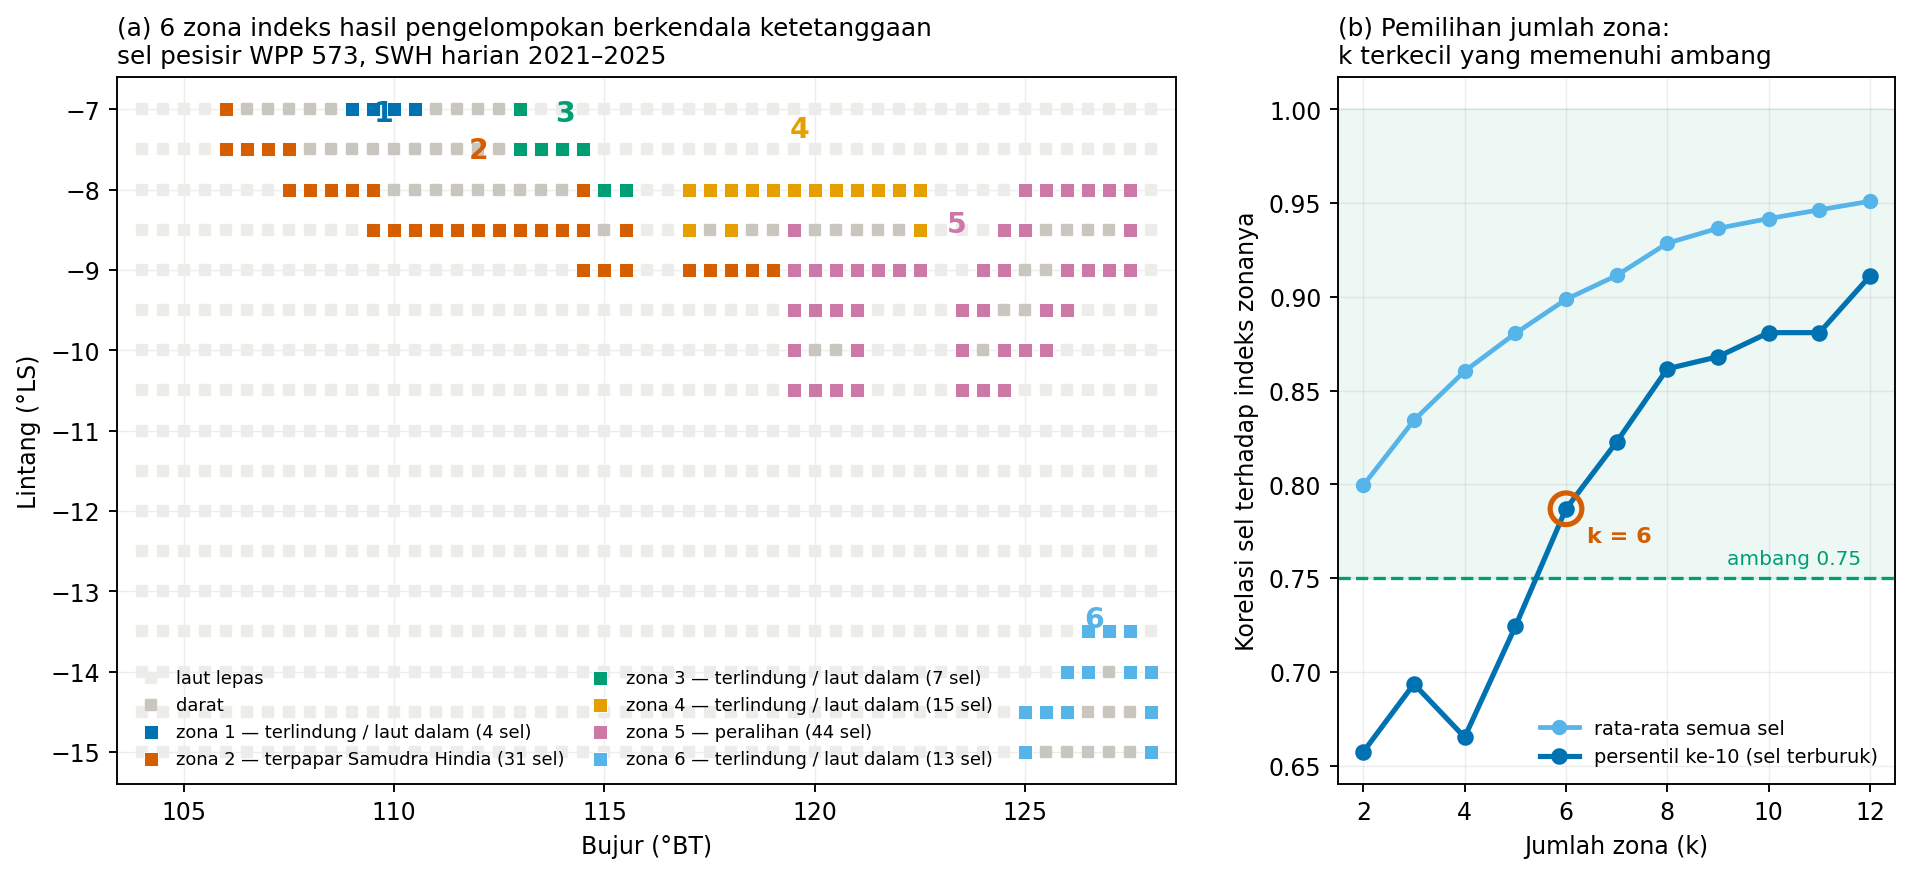

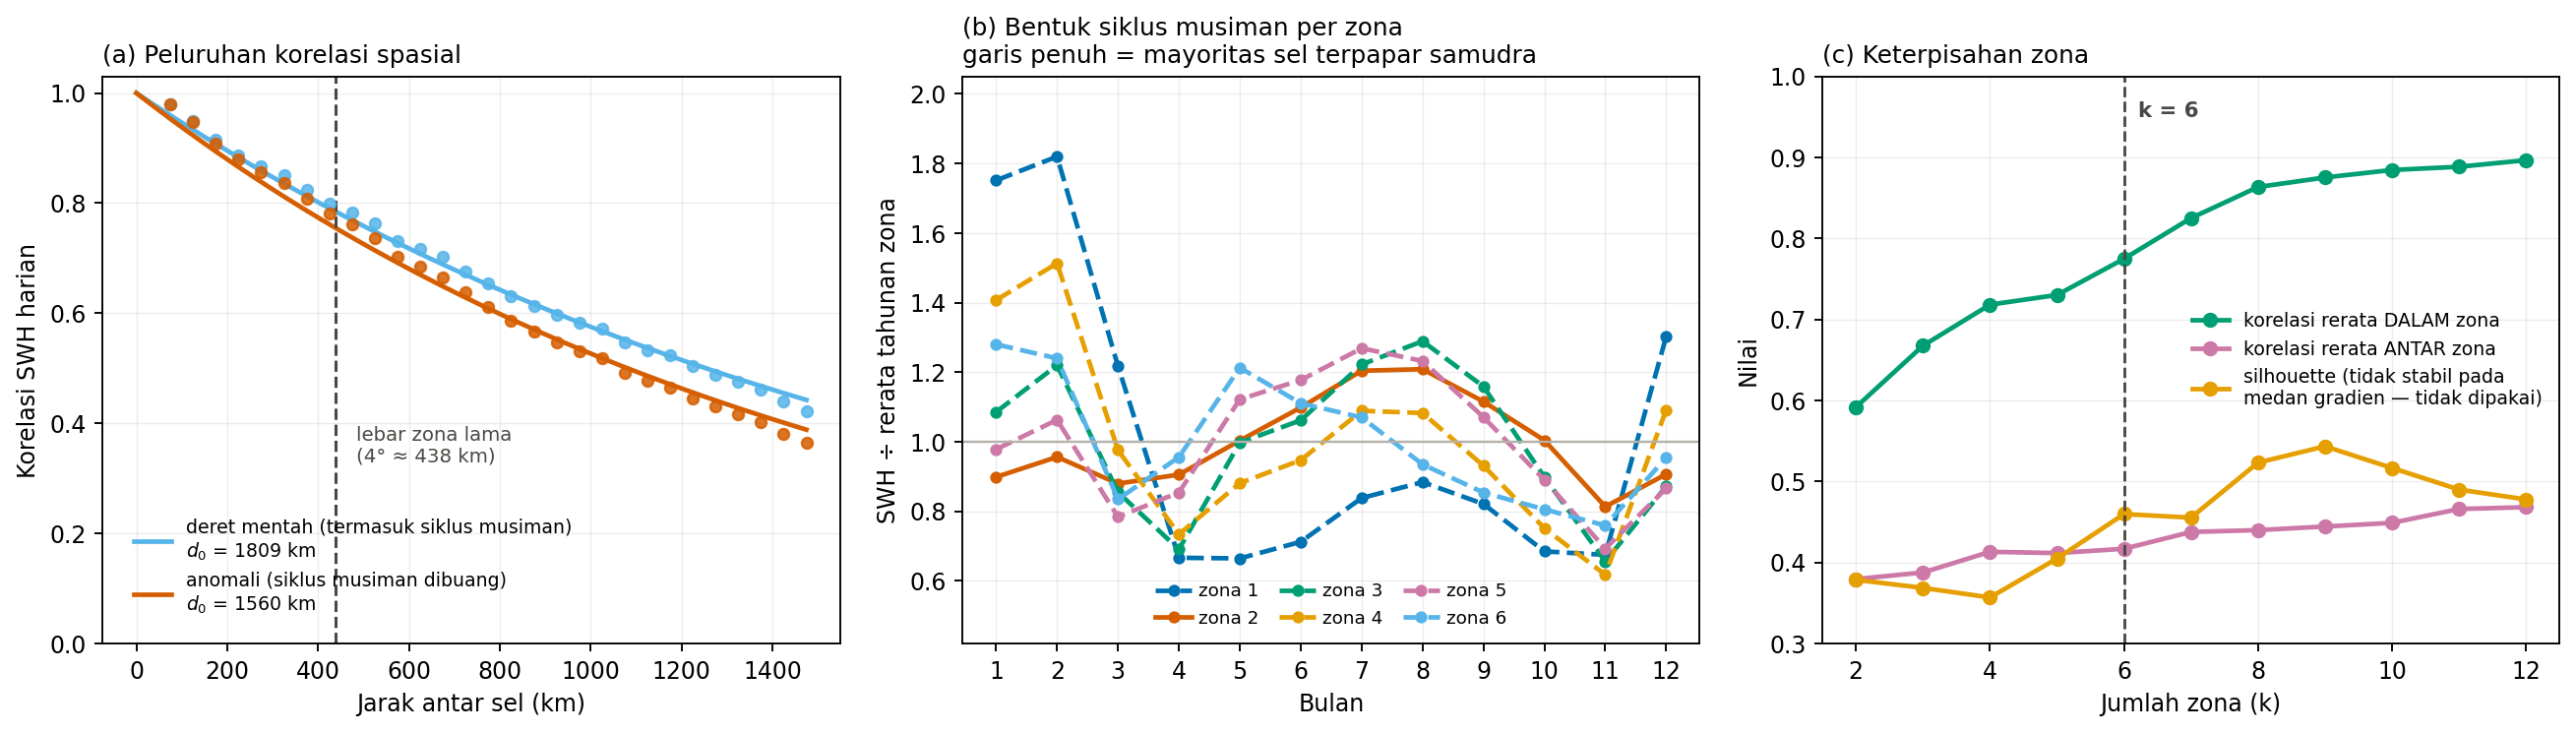

In [13]:
from IPython.display import Image, display

display(Image(filename=str(Z.FIG / "fig_zonasi_peta.png")))
display(Image(filename=str(Z.FIG / "fig_zonasi_diagnostik.png")))